In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_style("whitegrid")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math, time

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, roc_curve

# Import model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier, ExtraTreesClassifier
from catboost import CatBoostClassifier

In [3]:
df=pd.read_csv("../data/raw/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print(df.shape)  #no. of rows and columns 

(768, 9)


In [5]:
print(df.info())  #data type and count including non null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [6]:
print(df.isnull().sum())  #count the no. of missing values per column

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
zero_cols=['Glucose','BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[zero_cols]=df[zero_cols].replace(0,np.nan)

df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [8]:
# for col in zero_cols:
#     df[col]=df[col].fillna(df[col].median())
# df.isnull().sum()


# Step 2: Apply KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df[zero_cols] = imputer.fit_transform(df[zero_cols])

df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
#Feature Engg.
# Interaction features
df["BMI_Age"] = df["BMI"] * df["Age"]
df["Glucose_BMI"] = df["Glucose"] * df["BMI"]
df["Insulin_Glucose"] = df["Insulin"] / (df["Glucose"] + 1)

# Log transform (reduces skew)
df["Log_Insulin"] = np.log1p(df["Insulin"])

# Risk-based binary feature
df["High_Glucose"] = (df["Glucose"] > 125).astype(int)

# Optional: Age group bucket
df["Age_Group"] = pd.cut(df["Age"], bins=[20,30,40,50,60,100], labels=False)

In [10]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Age,Glucose_BMI,Insulin_Glucose,Log_Insulin,High_Glucose,Age_Group
0,6,148.0,72.0,35.0,209.0,33.6,0.627,50,1,1680.0,4972.8,1.402685,5.347108,1,2
1,1,85.0,66.0,29.0,73.0,26.6,0.351,31,0,824.6,2261.0,0.848837,4.304065,0,1
2,8,183.0,64.0,29.4,383.2,23.3,0.672,32,1,745.6,4263.9,2.082609,5.951163,1,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,590.1,2500.9,1.044444,4.553877,0,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,1422.3,5904.7,1.217391,5.129899,1,1


In [11]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (768, 14)
y shape: (768,)
Outcome
0    500
1    268
Name: count, dtype: int64


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (614, 14)
X_test : (154, 14)


In [13]:
# Checking stratification 
print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))


Train distribution:
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Test distribution:
 Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [14]:
num_cols = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols)
    ]
)

## Logistic Regression:

In [15]:
# Creting Model Pipeline
model = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

In [16]:
# Train Model
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

In [17]:
# Prediction
y_pred_lr = model.predict(X_test)

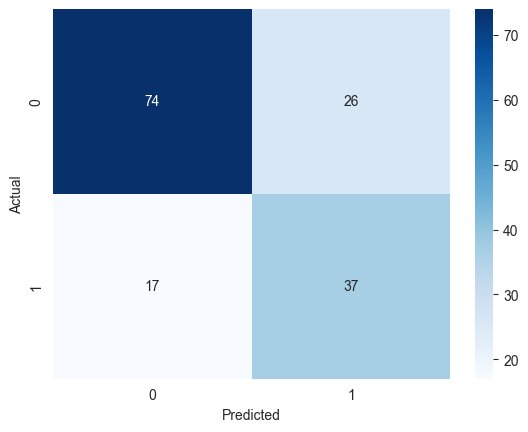



              precision    recall  f1-score   support

           0       0.81      0.74      0.77       100
           1       0.59      0.69      0.63        54

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154



ROC-AUC Score: 0.8122222222222223


In [18]:
# Evaluation
cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_lr))
print("\n")
y_prob_lr =model.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

## Voting Classifier

In [19]:
# Defining model
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier()
et = ExtraTreesClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

In [20]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',   # important
    metric='minkowski'
)

In [21]:
# creting voting classifer model
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('gb', gb),
        ('et', et),
        ('knn', knn)   
    ],
    voting='soft'
)

In [22]:
# creating voting pipeline
voting_pipeline = Pipeline(
   steps=[
       ("preprocessing", preprocessor),
       ("classifier", voting_model)
   ],
   verbose=True
)

In [23]:
# training
print("Starting Voting Classifier training...")
start_time = time.time()
voting_pipeline.fit(X_train, y_train)
end_time = time.time()
print("\nTraining completed.")
print(f"Total time taken: {end_time - start_time:.2f} seconds")

Starting Voting Classifier training...
[Pipeline] ..... (step 1 of 2) Processing preprocessing, total=   0.0s
[Pipeline] ........ (step 2 of 2) Processing classifier, total=   1.1s

Training completed.
Total time taken: 1.08 seconds


In [24]:
# Prediction
y_pred_voting = voting_pipeline.predict(X_test)

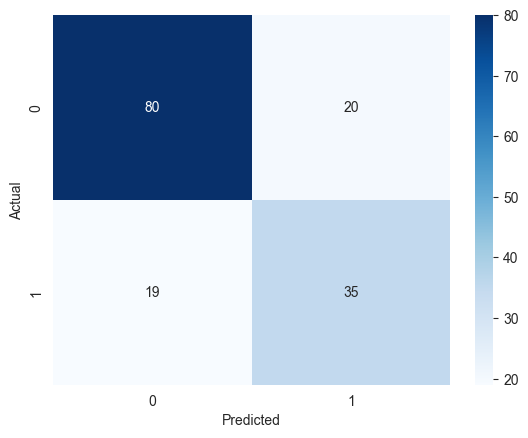



              precision    recall  f1-score   support

           0       0.81      0.80      0.80       100
           1       0.64      0.65      0.64        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



ROC-AUC Score: 0.8196296296296296


In [25]:
# Evaluation
cm = confusion_matrix(y_test, y_pred_voting)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\n")
print(classification_report(y_test, y_pred_voting))
print("\n")
y_prob_voting = voting_pipeline.predict_proba(X_test)[:, 1]
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_voting))